# Largest Year Investigation

**An Attempt at Determining Possible Causes to the Largest Posting and Commenting Years of Subreddits**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Posts

In [19]:
df = pd.read_csv(r'meta_data/subreddit_largest_post_year.csv')

### Get Counts for Largest Years

#### Basic Count

In [20]:
df['count'] = 1
grouped_df = df.groupby('largest_year')['count'].sum().reset_index()
grouped_df = grouped_df.rename(columns={'largest_year': 'year', 'count': 'subreddits'})

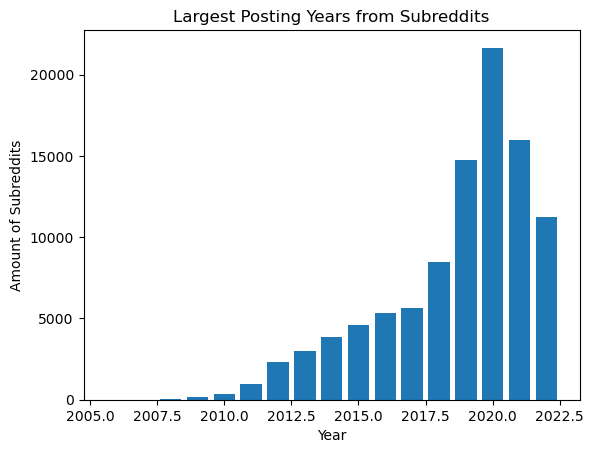

In [ ]:
# Create Graph of subreddits vs year
plt.bar(grouped_df['year'], grouped_df['subreddits'])
plt.title('Largest Posting Years from Subreddits'), plt.xlabel('Year'), plt.ylabel('Amount of Subreddits')
plt.show()

#### Confirmed COVID-19 Cases Overlay

**Note:** *confirmed cases* are measured by the millions

In [21]:
overlay_df = pd.read_csv(r'daily-new-confirmed-covid-19-cases-per-million-people.csv')

In [22]:
# Change day column to datetime
overlay_df['day'] = pd.to_datetime(overlay_df['day'])

# Create Year column
overlay_df['year'] = overlay_df['day'].dt.year

In [23]:
# Group by year and sum the cases
overlay_df = overlay_df.groupby('year')['confirmed'].sum().reset_index()

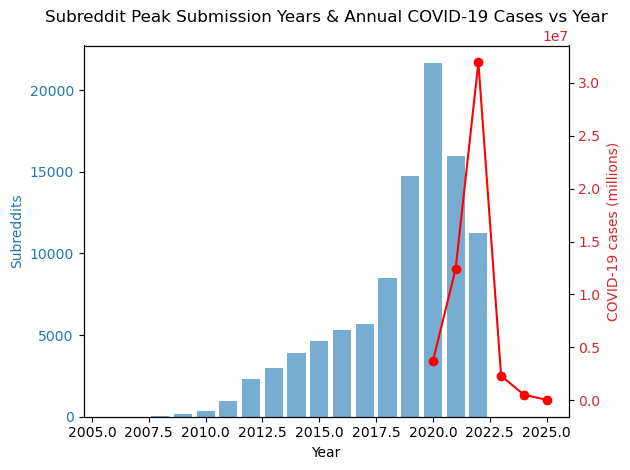

In [24]:
fig, ax1 = plt.subplots()

# Left axis: subreddit counts
ax1.bar(
    grouped_df['year'],
    grouped_df['subreddits'],
    alpha=0.6,
    label='Subreddits'
)
ax1.set_xlabel('Year')
ax1.set_ylabel('Subreddits', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right axis: COVID cases
ax2 = ax1.twinx()
ax2.plot(
    overlay_df['year'],
    overlay_df['confirmed'],
    color='red',
    marker='o',
    label='Confirmed Cases (Millions)'
)
ax2.set_ylabel('COVID‑19 cases (millions)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Legend
# ax1.legend(loc='upper left')
# ax2.legend(loc='upper right')

plt.title('Subreddit Peak Submission Years & Annual COVID‑19 Cases vs Year')
fig.tight_layout()
plt.show()


### t

## Comments

In [12]:
df = pd.read_csv(r'meta_data/subreddit_largest_comment_year.csv')

### Get Counts for Largest Years

#### Basic Count

In [13]:
df['count'] = 1
grouped_df = df.groupby('largest_year')['count'].sum().reset_index()
grouped_df = grouped_df.rename(columns={'largest_year': 'year', 'count': 'subreddits'})

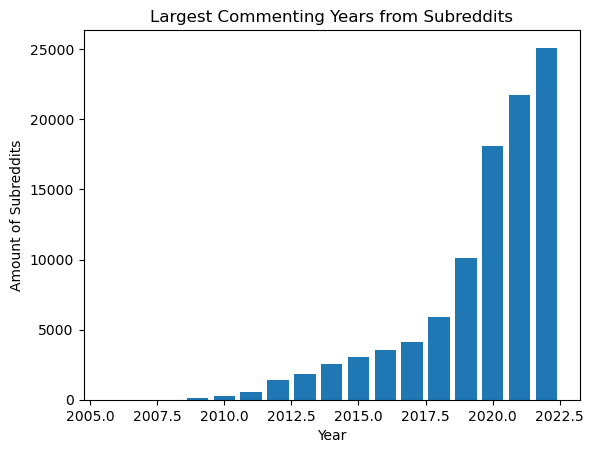

In [19]:
# Create Graph of subreddits vs year
plt.bar(grouped_df['year'], grouped_df['subreddits'])
plt.title('Largest Commenting Years from Subreddits'), plt.xlabel('Year'), plt.ylabel('Amount of Subreddits')
plt.show()

#### Confirmed COVID-19 Cases Overlay

**Note:** *confirmed cases* are measured by the millions

In [14]:
overlay_df = pd.read_csv(r'daily-new-confirmed-covid-19-cases-per-million-people.csv')

In [15]:
# Change day column to datetime
overlay_df['day'] = pd.to_datetime(overlay_df['day'])

# Create Year column
overlay_df['year'] = overlay_df['day'].dt.year

In [16]:
# Group by year and sum the cases
overlay_df = overlay_df.groupby('year')['confirmed'].sum().reset_index()

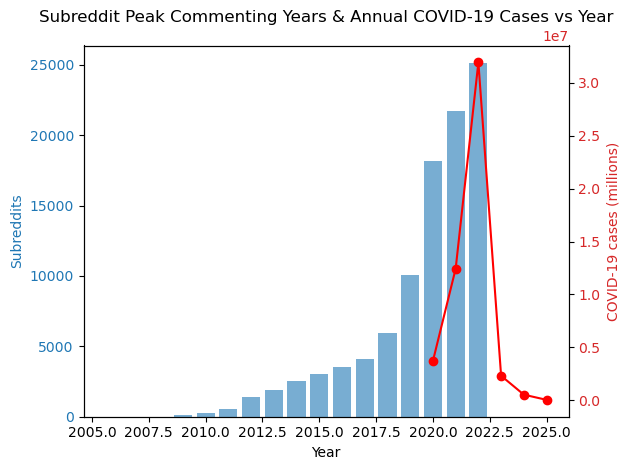

In [18]:
fig, ax1 = plt.subplots()

# Left axis: subreddit counts
ax1.bar(
    grouped_df['year'],
    grouped_df['subreddits'],
    alpha=0.6,
    label='Subreddits'
)
ax1.set_xlabel('Year')
ax1.set_ylabel('Subreddits', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right axis: COVID cases
ax2 = ax1.twinx()
ax2.plot(
    overlay_df['year'],
    overlay_df['confirmed'],
    color='red',
    marker='o',
    label='Confirmed Cases (Millions)'
)
ax2.set_ylabel('COVID‑19 cases (millions)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Legend
# ax1.legend(loc='upper left')
# ax2.legend(loc='upper right')

plt.title('Subreddit Peak Commenting Years & Annual COVID‑19 Cases vs Year')
fig.tight_layout()
plt.show()